In [29]:
# LIBRERÍAS A USAR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

In [30]:
## Cargamos los datos
data = pd.read_excel("dataset_didactico_machine_learning - ALUMNOS - copia.xlsx")

data.head()



,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


#### Visualizaciones

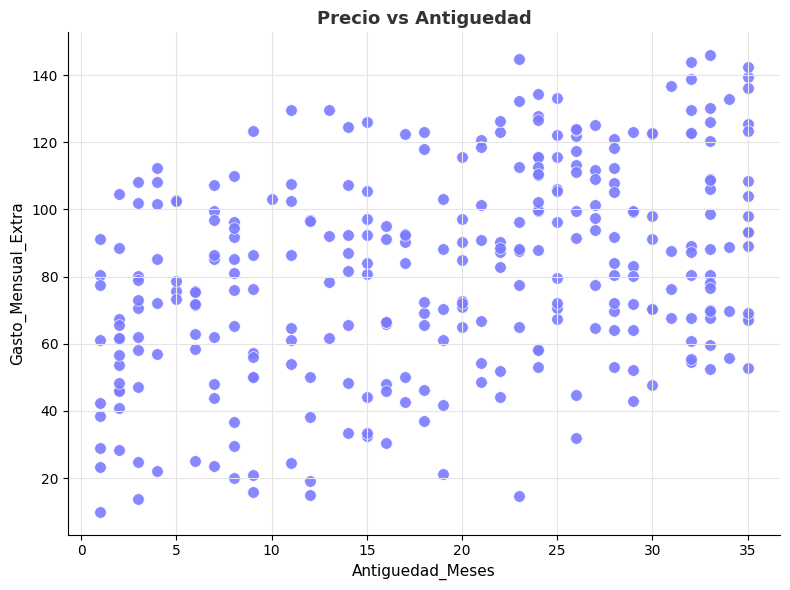

In [31]:
# Scatterplot: Antiguedad vs Precio
plt.figure(figsize=(8, 6))
plt.scatter(
    data["Antiguedad_Meses"],
    data["Gasto_Mensual_Extra"],
    color="#7a7bff",
    edgecolor="white",
    linewidth=0.5,
    s=70,
    alpha=0.9,
)
plt.xlabel("Antiguedad_Meses", fontsize=11)
plt.ylabel("Gasto_Mensual_Extra", fontsize=11)
plt.title("Precio vs Antiguedad", fontsize=13, fontweight="bold", color="#333333")
plt.grid(color="#e5e5e5", linestyle="-", linewidth=0.8)
plt.gca().set_facecolor("white")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

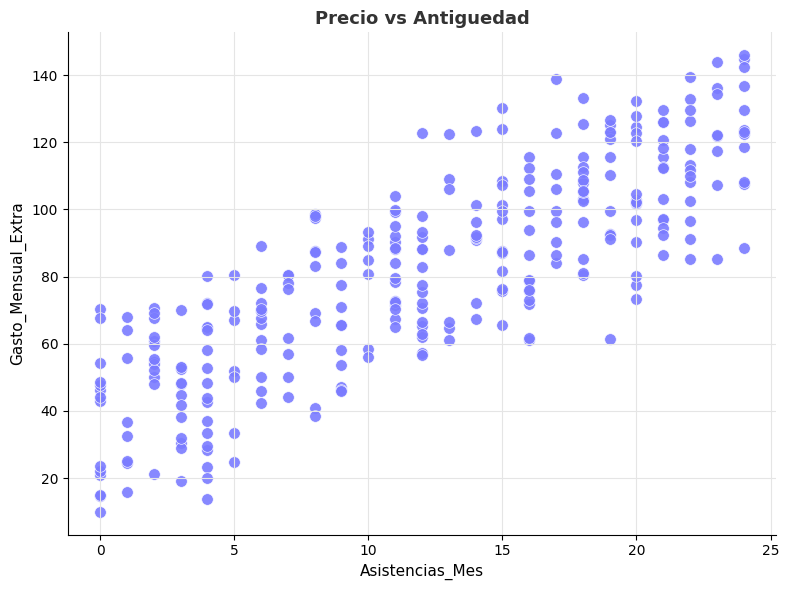

In [32]:
# Scatterplot: Asistencia vs Precio
plt.figure(figsize=(8, 6))
plt.scatter(
    data["Asistencias_Mes"],
    data["Gasto_Mensual_Extra"],
    color="#7a7bff",
    edgecolor="white",
    linewidth=0.5,
    s=70,
    alpha=0.9,
)
plt.xlabel("Asistencias_Mes", fontsize=11)
plt.ylabel("Gasto_Mensual_Extra", fontsize=11)
plt.title("Precio vs Antiguedad", fontsize=13, fontweight="bold", color="#333333")
plt.grid(color="#e5e5e5", linestyle="-", linewidth=0.8)
plt.gca().set_facecolor("white")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

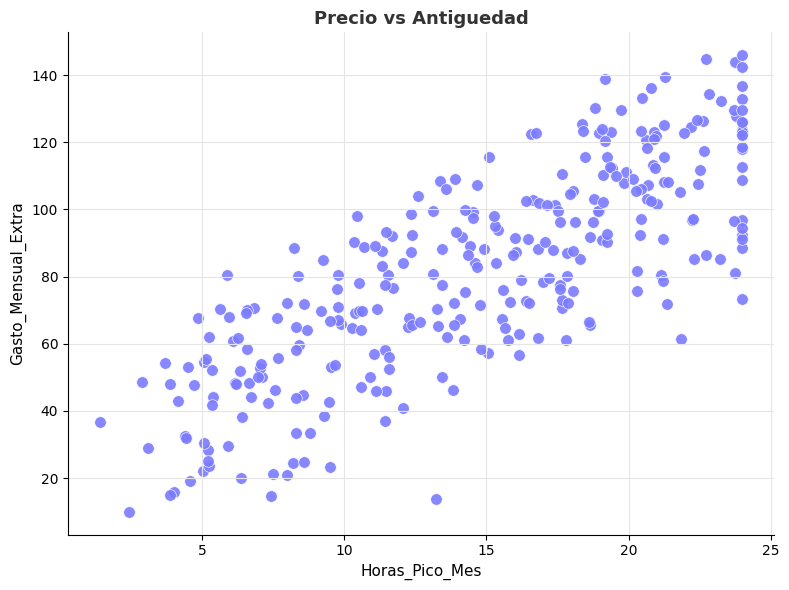

In [33]:
# Scatterplot: Horas pico vs Precio
plt.figure(figsize=(8, 6))
plt.scatter(
    data["Horas_Pico_Mes"],
    data["Gasto_Mensual_Extra"],
    color="#7a7bff",
    edgecolor="white",
    linewidth=0.5,
    s=70,
    alpha=0.9,
)
plt.xlabel("Horas_Pico_Mes", fontsize=11)
plt.ylabel("Gasto_Mensual_Extra", fontsize=11)
plt.title("Precio vs Antiguedad", fontsize=13, fontweight="bold", color="#333333")
plt.grid(color="#e5e5e5", linestyle="-", linewidth=0.8)
plt.gca().set_facecolor("white")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Construcción del modelo de regresión

In [34]:
#Antes estudiamos la correlacion entre las variables


correlacion = data.corr(numeric_only=True)["Gasto_Mensual_Extra"].sort_values(ascending=False)

print(correlacion)

Gasto_Mensual_Extra    1.000000
Asistencias_Mes        0.824125
Horas_Pico_Mes         0.795854
Satisfecho             0.623006
Antiguedad_Meses       0.383799
ID_Cliente             0.043968
Abandono              -0.587383
Name: Gasto_Mensual_Extra, dtype: float64


In [35]:
modelo_simple = ols('Gasto_Mensual_Extra ~ Asistencias_Mes', data=data).fit()

In [36]:
#Mostrar resultados de la modelizacion

# Mostrar resultados de la modelizacion

print("\n--- RESUMEN DEL MODELO ---")
print(modelo_simple.summary().tables[1])
print("R2:", round(modelo_simple.rsquared, 4))
print("R2-ajustado:", round(modelo_simple.rsquared_adj, 4))


--- RESUMEN DEL MODELO ---
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          39.6759      1.948     20.370      0.000      35.843      43.509
Asistencias_Mes     3.4550      0.138     25.117      0.000       3.184       3.726
R2: 0.6792
R2-ajustado: 0.6781


In [ ]:
## Ahora con las 3 variables

print("CASO 2 Regresión Multiple sin colinealidad")

modelo_multiple = ols('Gasto_Mensual_Extra ~ Antiguedad_Meses + Horas_Pico_Mes', data=data).fit()

# Mostrar resultados de la modelizacion

print("\n--- RESUMEN DEL MODELO ---")
print(modelo_multiple.summary().tables[1])
print("R2:", round(modelo_multiple.rsquared, 4))
print("R2-ajustado:", round(modelo_multiple.rsquared_adj, 4))

CASO 2 Regresión Multiple sin colinealidad

--- RESUMEN DEL MODELO ---
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.6686      2.546      0.263      0.793      -4.342       5.679
Antiguedad_Meses     1.1603      0.075     15.414      0.000       1.012       1.308
Horas_Pico_Mes       4.0297      0.131     30.764      0.000       3.772       4.287
R2: 0.7963
R2-ajustado: 0.795


In [18]:
# Obtener las predecciones del modelo

valores_predichos= modelo_simple.fittedvalues

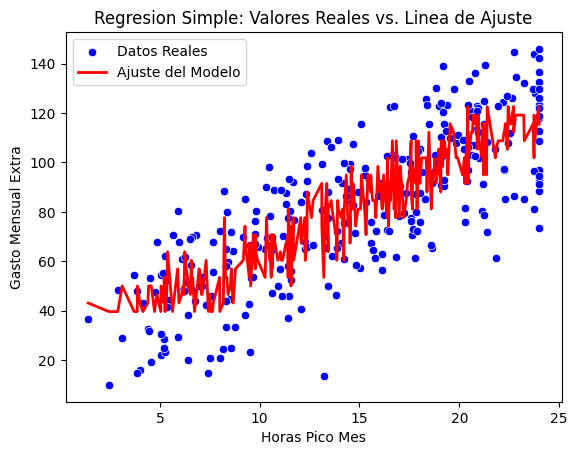

In [19]:
# Calcular los valores que el modelo predice para cada vivienda del dataset
valores_predichos = modelo_simple.fittedvalues


# Visualizar
sns.scatterplot(x=data['Horas_Pico_Mes'], y=data['Gasto_Mensual_Extra'], color='blue', label='Datos Reales')
sns.lineplot(x=data['Horas_Pico_Mes'], y=valores_predichos, color='red', linewidth=2, label='Ajuste del Modelo')
plt.title("Regresion Simple: Valores Reales vs. Linea de Ajuste")
plt.xlabel('Horas Pico Mes')
plt.ylabel('Gasto Mensual Extra')
plt.legend()
plt.show()


--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---
Variable Asistencias_Mes : VIF = 8.95
Variable Horas_Pico_Mes : VIF = 8.95

Determinante: 0.1117
No se observan problemas importantes de multicolinealidad


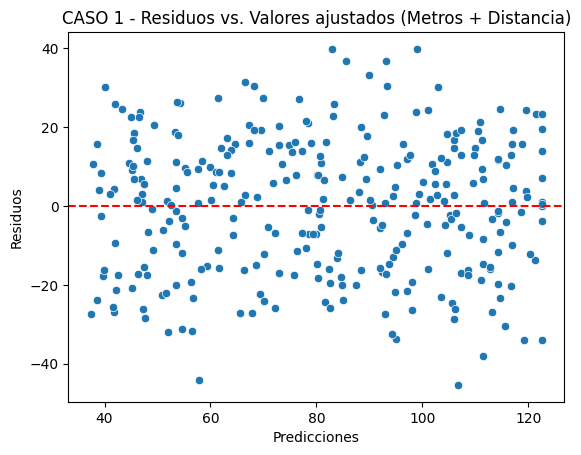

In [20]:
# ====================================================
# CASO 1: Hora pico mes + Gasto Mensual Extra (2 variables)
# ====================================================

modelo_caso1 = ols(
    "Gasto_Mensual_Extra ~ Asistencias_Mes + Horas_Pico_Mes",
    data=data,
).fit()

# Calcular VIF
print("\n--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---")
matriz_x_1 = modelo_caso1.model.exog
for i in range(1, matriz_x_1.shape[1]):
    vif = variance_inflation_factor(matriz_x_1, i)
    print("Variable", modelo_caso1.model.exog_names[i], ": VIF =", round(vif, 2))

# Calcular el determinante de la matriz de correlación
X1 = data[["Asistencias_Mes", "Horas_Pico_Mes"]]
matriz_corre_1 = X1.corr()
determinante_1 = np.linalg.det(matriz_corre_1)
print("\nDeterminante:", round(determinante_1, 4))

if determinante_1 < 0.01:
    print("Existe fuerte evidencia de multicolinealidad")
elif determinante_1 < 0.1:
    print("Existe cierta multicolinealidad")
else:
    print("No se observan problemas importantes de multicolinealidad")

# Grafico de residuos
valores_ajustados_1 = modelo_caso1.fittedvalues
residuos_1 = modelo_caso1.resid

sns.scatterplot(x=valores_ajustados_1, y=residuos_1)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
plt.title("CASO 1 - Residuos vs. Valores ajustados (Metros + Distancia)")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()

In [ ]:
# Ahora con las 3 viariables

print("CASO 2 Regresión Multiple sin colinealidad")

modelo_multiple = ols('Gasto_Mensual_Extra ~ Antiguedad_Meses + Asistencias_Mes + Horas_Pico_Mes', data=data).fit()

# Mostrar resultados de la modelizacion

print("\n--- RESUMEN DEL MODELO ---")
print(modelo_multiple.summary().tables[1])
print("R2:", round(modelo_multiple.rsquared, 4))
print("R2-ajustado:", round(modelo_multiple.rsquared_adj, 4))

CASO 2 Regresión Multiple sin colinealidad

--- RESUMEN DEL MODELO ---
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           13.9161      2.190      6.354      0.000       9.606      18.227
Antiguedad_Meses     1.2845      0.059     21.736      0.000       1.168       1.401
Asistencias_Mes      3.6185      0.258     14.032      0.000       3.111       4.126
Horas_Pico_Mes      -0.0328      0.307     -0.107      0.915      -0.637       0.571
R2: 0.8777
R2-ajustado: 0.8764
